In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

In [4]:
gdp = pd.read_csv("cleaned gdp data.csv")
population = pd.read_csv("cleaned population data.csv")
ghg = pd.read_csv("cleaned GHG data.csv")

In [6]:
gdp_vertical = gdp.melt(
    id_vars = "Country Name", 
    var_name = "Year",
    value_name = "GDP"
)

population_vertical = population.melt(
    id_vars = "Country Name", 
    var_name = "Year", 
    value_name = "Population"
)

ghg_vertical = ghg.melt(
    id_vars = "Country Name", 
    var_name = "Year",
    value_name = "GHG"
)

In [7]:
merged = gdp_vertical.merge(population_vertical, on = ["Country Name", "Year"])
merged2 = merged.merge(ghg_vertical, on = ["Country Name", "Year"])

merged2["Year"] = merged2["Year"].astype(int)
merged2["GHG"] = merged2["GHG"].str.replace(",", "")
merged2["GHG"] = merged2["GHG"].astype(float)


In [8]:
merged2["GDP_per_capita"] = merged2["GDP"] / merged2["Population"]
merged2["GHG_per_capita"] = merged2["GHG"] / merged2["Population"]

In [9]:
merged2.to_csv("final_merged_data.csv", index=False)

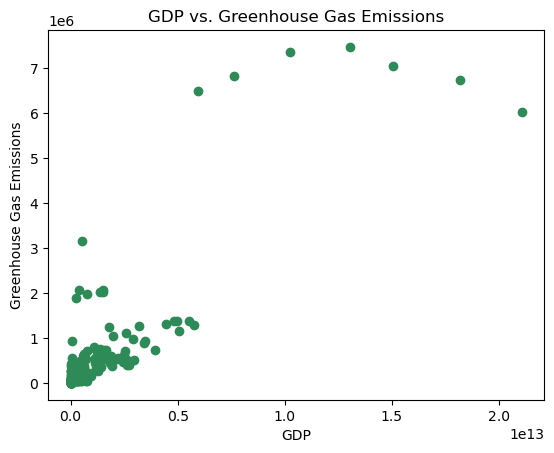

<Figure size 800x600 with 0 Axes>

In [16]:
plt.scatter(merged2["GDP"], merged2["GHG"], color="seagreen")
plt.xlabel("GDP")
plt.ylabel("Greenhouse Gas Emissions")
plt.title("GDP vs. Greenhouse Gas Emissions")
plt.savefig("../static/gdp_vs.ghg.png", bbox_inches="tight")
plt.figure(figsize=(8,6))
plt.show()

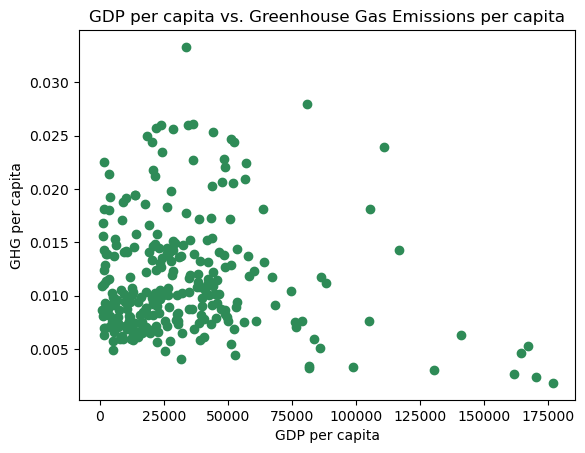

<Figure size 800x600 with 0 Axes>

In [17]:
plt.scatter(merged2["GDP_per_capita"], merged2["GHG_per_capita"], color="seagreen")
plt.xlabel("GDP per capita")
plt.ylabel("GHG per capita")
plt.title("GDP per capita vs. Greenhouse Gas Emissions per capita")
plt.savefig("../static/gdp_per_capita_vs.ghg_per_capita.png", bbox_inches="tight")
plt.figure(figsize=(8,6))
plt.show()


In [20]:
df = pd.read_csv("final_merged_data.csv")
df = df.rename(columns={
    "Country Name": "country", 
    "Year": "year",
    "GDP": "gdp",
    "Population": "population",
    "GHG": "ghg",
    "GDP_per_capita": "gdp_per_capita",
    "GHG_per_capita": "ghg_per_capita"
})

df.head()

,country,year,gdp,population,ghg,gdp_per_capita,ghg_per_capita
0,Australia,1990,3.118407e+11,17065128,425624.31,18273.561526,0.024941
1,Austria,1990,1.658114e+11,7677850,79047.23,21596.068220,0.010295
2,Belarus,1990,1.738956e+10,10189348,145339.89,1706.640919,0.014264
3,Belgium,1990,2.053317e+11,9967379,145844.47,20600.375279,0.014632
4,Bulgaria,1990,2.063209e+10,8718289,98910.34,2366.529821,0.011345


In [21]:
conn = sqlite3.connect("database.db")
cursor = conn.cursor()

cursor.execute("DROP TABLE IF EXISTS indicator")
cursor.execute("""
               CREATE TABLE indicator 
               (country TEXT, 
               year INTEGER,
               gdp REAL,
               ghg REAL,
               gdp_per_capita REAL,
               ghg_per_capita REAL
               );
               """)

df.to_sql("indicator", conn, if_exists ="append", index = False)

conn.commit()
conn.close()

OperationalError: table indicator has no column named population